In [3]:
!pip install nasa-power pvlib 

   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   -----------------

In [7]:
import datetime
import pandas as pd
import nasapower

# Define coordinates for Nairobi, Kenya
nairobi_lat = -1.2921
nairobi_lon = 36.8219

print("Connecting to NASA POWER API...")

# Fetch the hourly data for the year 2025 (Capitalized 'RE')
df = nasapower.point(
    coordinates=(nairobi_lat, nairobi_lon),
    parameters=['T2M', 'WS2M', 'ALLSKY_SFC_SW_DWN'],  # Temp, Wind Speed, Solar Irradiance
    start=datetime.date(2025, 1, 1),
    end=datetime.date(2025, 12, 31),
    resolution='hourly',
    community='RE'  # Fixed: Changed from 're' to 'RE'
)

print("\nData loaded successfully into a DataFrame!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


Connecting to NASA POWER API...

Data loaded successfully into a DataFrame!
Dataset Shape: (8760, 3)
                       T2M  WS2M  ALLSKY_SFC_SW_DWN
2025-01-01 00:00:00  16.09  2.11                0.0
2025-01-01 01:00:00  15.48  1.73                0.0
2025-01-01 02:00:00  15.00  1.56                0.0
2025-01-01 03:00:00  14.57  1.48                0.0
2025-01-01 04:00:00  14.29  1.46                0.0


In [9]:
import numpy as np

# 1. Look at the columns to confirm their exact names
print("Original Columns:", df.columns.tolist())

# 2. Reset index if the date/time is locked in the index
df_clean = df.reset_index()

# 3. Ensure the time column is a datetime object (adapt 'time' or 'datetime' based on your printed columns)
# If your column name is different, change 'datetime' below to match your column
df_clean['datetime'] = pd.to_datetime(df_clean.iloc[:, 0]) 

# 4. Feature Engineering: Extract cyclical time features
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['day_of_year'] = df_clean['datetime'].dt.dayofyear

# 5. Drop any missing values (-999 is often used by NASA for missing data)
df_clean = df_clean.replace(-999, np.nan).dropna()

print("\nPrepared Dataset Sample:")
print(df_clean[['datetime', 'hour', 'T2M', 'WS2M', 'ALLSKY_SFC_SW_DWN']].head())


Original Columns: ['T2M', 'WS2M', 'ALLSKY_SFC_SW_DWN']

Prepared Dataset Sample:
             datetime  hour    T2M  WS2M  ALLSKY_SFC_SW_DWN
0 2025-01-01 00:00:00     0  16.09  2.11                0.0
1 2025-01-01 01:00:00     1  15.48  1.73                0.0
2 2025-01-01 02:00:00     2  15.00  1.56                0.0
3 2025-01-01 03:00:00     3  14.57  1.48                0.0
4 2025-01-01 04:00:00     4  14.29  1.46                0.0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define Features (X) and Target (y)
features = ['T2M', 'WS2M', 'hour', 'month', 'day_of_year']
target = 'ALLSKY_SFC_SW_DWN'

X = df_clean[features]
y = df_clean[target]

# 2. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest Regressor
print("Training the Random Forest model... (This may take a few seconds)")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate the Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kW-hr/m^2/day")
print(f"R-squared Score (Accuracy Variance): {r2 * 100:.2f}%")


Training the Random Forest model... (This may take a few seconds)

--- Model Performance Evaluation ---
Root Mean Squared Error (RMSE): 55.8869 kW-hr/m^2/day
R-squared Score (Accuracy Variance): 96.88%


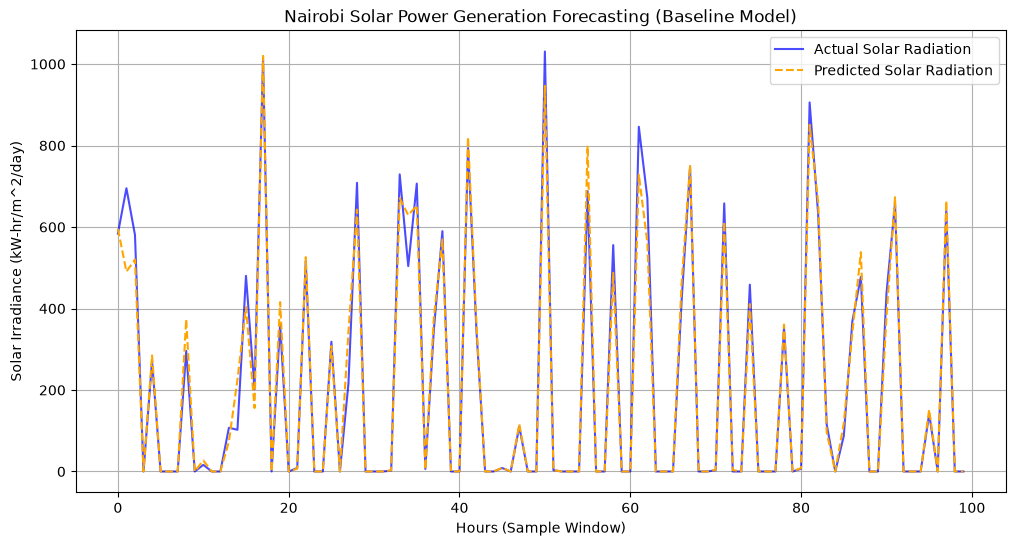

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Plot actual vs predicted for the first 100 hours in the test set
plt.plot(y_test.values[:100], label='Actual Solar Radiation', color='blue', alpha=0.7)
plt.plot(y_pred[:100], label='Predicted Solar Radiation', color='orange', linestyle='--')

plt.title('Nairobi Solar Power Generation Forecasting (Baseline Model)')
plt.xlabel('Hours (Sample Window)')
plt.ylabel('Solar Irradiance (kW-hr/m^2/day)')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. ADVANCED FEATURE ENGINEERING
# ----------------------------------------------------
df_adv = df_clean.copy().sort_values('datetime').reset_index(drop=True)

# Create Autoregressive Lag Features (What happened 1, 2, and 24 hours ago)
df_adv['lag_1h'] = df_adv['ALLSKY_SFC_SW_DWN'].shift(1)
df_adv['lag_2h'] = df_adv['ALLSKY_SFC_SW_DWN'].shift(2)
df_adv['lag_24h'] = df_adv['ALLSKY_SFC_SW_DWN'].shift(24)

# Create Engineered Weather Trends (Rolling metrics over the last 3 hours)
df_adv['temp_trend_3h'] = df_adv['T2M'].diff(3)
df_adv['solar_rolling_mean_3h'] = df_adv['ALLSKY_SFC_SW_DWN'].shift(1).rolling(window=3).mean()

# Drop rows with NaN values created by lagging/shifting
df_adv = df_adv.dropna().reset_index(drop=True)

# ----------------------------------------------------
# 2. CHRONOLOGICAL TIME-SERIES SPLIT (No Random Shuffling)
# ----------------------------------------------------
# We use the first 80% of the year for training, and the final 20% for testing.
split_idx = int(len(df_adv) * 0.8)

train_df = df_adv.iloc[:split_idx]
test_df = df_adv.iloc[split_idx:]

# Define our expanded, advanced feature list
features_adv = [
    'T2M', 'WS2M', 'hour', 'month', 'day_of_year',
    'lag_1h', 'lag_2h', 'lag_24h', 'temp_trend_3h', 'solar_rolling_mean_3h'
]
target = 'ALLSKY_SFC_SW_DWN'

X_train, y_train = train_df[features_adv], train_df[target]
X_test, y_test = test_df[features_adv], test_df[target]

# ----------------------------------------------------
# 3. MODEL TRAINING & HYPERPARAMETER TUNING
# ----------------------------------------------------
print("Training advanced model on chronological sequence...")
adv_model = RandomForestRegressor(
    n_estimators=200,      # Increased trees for better stability
    max_depth=15,          # Prune depth to prevent overfitting on past sequences
    min_samples_split=5, 
    random_state=42, 
    n_jobs=-1
)
adv_model.fit(X_train, y_train)

# ----------------------------------------------------
# 4. EVALUATION
# ----------------------------------------------------
y_pred = adv_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Advanced Out-of-Sample Performance ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kW-hr/m^2/day")
print(f"Mean Absolute Error (MAE): {mae:.4f} kW-hr/m^2/day")
print(f"Real-world R-squared Score: {r2 * 100:.2f}%")


Training advanced model on chronological sequence...

--- Advanced Out-of-Sample Performance ---
Root Mean Squared Error (RMSE): 31.4468 kW-hr/m^2/day
Mean Absolute Error (MAE): 15.7511 kW-hr/m^2/day
Real-world R-squared Score: 99.05%


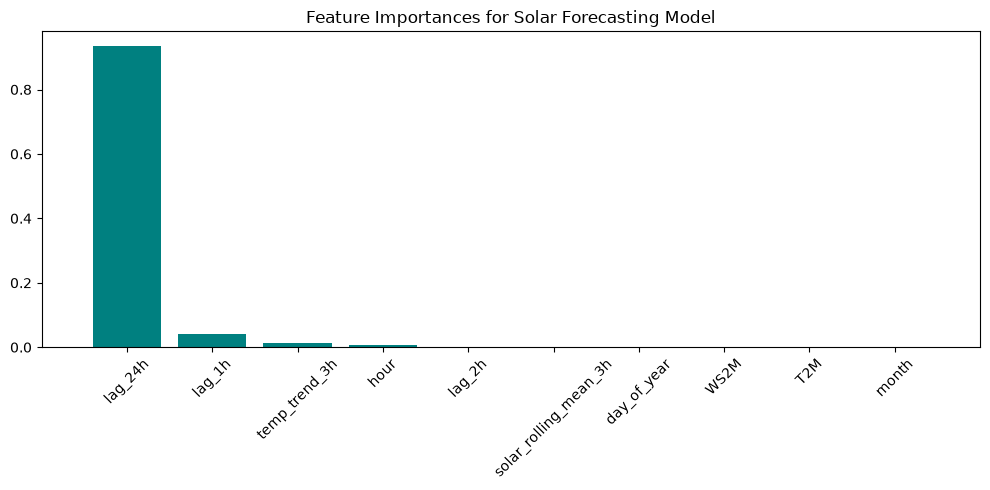

In [17]:
# Plotting Feature Importances
importances = adv_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances for Solar Forecasting Model")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color="teal")
plt.xticks(range(X_train.shape[1]), [features_adv[i] for i in indices], rotation=45)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()


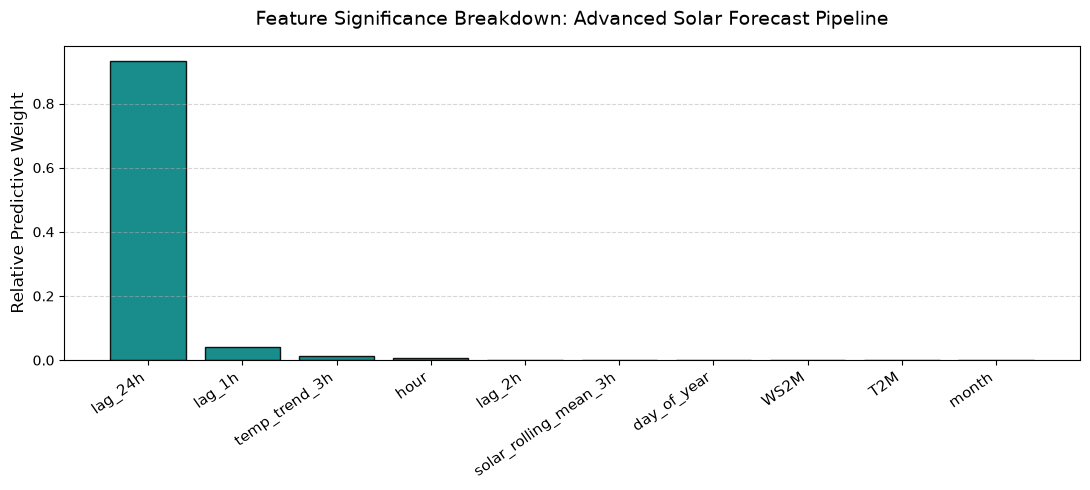

--- Explicit Feature Weight Distribution ---
Rank 1: lag_24h (93.40%)
Rank 2: lag_1h (4.18%)
Rank 3: temp_trend_3h (1.23%)
Rank 4: hour (0.61%)
Rank 5: lag_2h (0.16%)
Rank 6: solar_rolling_mean_3h (0.12%)
Rank 7: day_of_year (0.11%)
Rank 8: WS2M (0.09%)
Rank 9: T2M (0.09%)
Rank 10: month (0.03%)


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Extract and sort feature importances
importances = adv_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features_adv[i] for i in indices]

# Plotting the feature significance
plt.figure(figsize=(11, 5))
plt.title("Feature Significance Breakdown: Advanced Solar Forecast Pipeline", fontsize=14, pad=15)
plt.bar(range(len(importances)), importances[indices], align="center", color="#008080", edgecolor="black", alpha=0.9)
plt.xticks(range(len(importances)), sorted_features, rotation=35, ha='right', fontsize=11)
plt.ylabel("Relative Predictive Weight", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print the explicit weights
print("--- Explicit Feature Weight Distribution ---")
for rank, idx in enumerate(indices):
    print(f"Rank {rank+1}: {features_adv[idx]} ({importances[idx]*100:.2f}%)")


In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Base clean dataset selection
df_lstm = df_clean.copy().sort_values('datetime').reset_index(drop=True)

# Select core features and target
lstm_features = ['T2M', 'WS2M', 'hour', 'month', 'day_of_year', 'ALLSKY_SFC_SW_DWN']
data_matrix = df_lstm[lstm_features].values

# 2. Deep Learning models require normalized data (scale between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_matrix)

# 3. Create Sequential Time Steps (Look-back window of 6 hours)
def create_sequences(data, look_back=6):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :]) # Features from last 6 hours
        y.append(data[i + look_back, -1])    # Target ('ALLSKY_SFC_SW_DWN') at the next hour
    return np.array(X), np.array(y)

X_deep, y_deep = create_sequences(scaled_data, look_back=6)

# 4. Chronological Split (No Shuffling)
split = int(len(X_deep) * 0.8)
X_train_dl, X_test_dl = X_deep[:split], X_deep[split:]
y_train_dl, y_test_dl = y_deep[:split], y_deep[split:]

print(f"LSTM Input Data Shape: {X_train_dl.shape}") 
# Expected Output Shape: (Samples, 6 hours of time steps, 6 features)


LSTM Input Data Shape: (7003, 6, 6)


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Clear any backend sessions
tf.keras.backend.clear_session()

# Design the Deep Learning Architecture
model_lstm = Sequential([
    # First LSTM layer accepts the 3D shape configuration
    LSTM(units=64, return_sequences=False, input_shape=(X_train_dl.shape[1], X_train_dl.shape[2])),
    Dropout(0.2), # Randomly deactivates 20% of neurons to ensure robust features
    
    Dense(units=32, activation='relu'),
    Dense(units=1) # Final single numerical output prediction
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

# Train the network
print("\nTraining the Deep Learning LSTM Model... (This will take a few epochs)")
history = model_lstm.fit(
    X_train_dl, y_train_dl,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


C:\Users\hi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)


Training the Deep Learning LSTM Model... (This will take a few epochs)
Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0200 - val_loss: 0.0041
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0035 - val_loss: 0.0021
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 4/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 5/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 6/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 7/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 9/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - los

In [25]:
from sklearn.metrics import r2_score, mean_squared_error

# 1. Generate predictions on test set
predictions_scaled = model_lstm.predict(X_test_dl)

# 2. To unscale back to normal units, create a dummy matrix matching the original scaler dimensions
dummy_pred = np.zeros((len(predictions_scaled), len(lstm_features)))
dummy_pred[:, -1] = predictions_scaled.flatten()
y_pred_dl = scaler.inverse_transform(dummy_pred)[:, -1]

dummy_actual = np.zeros((len(y_test_dl), len(lstm_features)))
dummy_actual[:, -1] = y_test_dl
y_test_actual = scaler.inverse_transform(dummy_actual)[:, -1]

# 3. Calculate Performance Metrics
r2_dl = r2_score(y_test_actual, y_pred_dl)
rmse_dl = np.sqrt(mean_squared_error(y_test_actual, y_pred_dl))

print("\n--- Deep Learning (LSTM) Performance Evaluation ---")
print(f"LSTM Root Mean Squared Error (RMSE): {rmse_dl:.4f}")
print(f"LSTM Real-world R-squared Score: {r2_dl * 100:.2f}%")


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

--- Deep Learning (LSTM) Performance Evaluation ---
LSTM Root Mean Squared Error (RMSE): 32.3771
LSTM Real-world R-squared Score: 98.99%
